**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: MLOPS**

Tecnológico de Monterrey


**Proyecto Entrega 1**


---

In [146]:
import pandas as pd
import numpy as np
import seaborn as sns

In [147]:
df = pd.read_csv('online_news_modified.csv', delimiter=',')


# ***EDA***

Estadísticas descriptivas para todas las variables del dataframe.

In [148]:
#PRIMERAS FILAS
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,mixed_type_col
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594466988,0.999999992308,0.815384609112,4.0,2.0,1.0,...,0.7,-0.35,-0.6,-3.4000000000000004,0.5,-0.1875,0.0,0.1875,593.0,bad
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743080614,0.999999993289,0.79194630341,3.0,1.0,1.0,...,0.7,-0.11875,-0.125,-0.1,0.0,0.0,0.5,0.0,711.0,639
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575129530699,0.999999991597,0.66386554064,3.0,1.0,1.0,...,1.0,-0.466666666667,-0.8,-0.133333333333,0.0,0.0,0.5,0.0,1500.0,unknown
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503787877834,0.999999996904,0.665634672862,9.0,0.0,1.0,...,0.8,-0.369696969697,-0.6,-0.166666666667,0.0,0.0,0.5,NaN,1200.0,688
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.41564561695,0.999999998565,0.540889525766,19.0,19.0,20.0,...,1.0,-0.220192307692,error,-0.05,0.454545454545,0.136363636364,0.0454545454545,0.136363636364,505.0,579


In [149]:
#INFORMACIÓN DE TIPOS DE DATOS
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40436 entries, 0 to 40435
Data columns (total 62 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   url                            40027 non-null  object
 1   timedelta                      39994 non-null  object
 2   n_tokens_title                 39976 non-null  object
 3   n_tokens_content               39963 non-null  object
 4   n_unique_tokens                39985 non-null  object
 5   n_non_stop_words               39977 non-null  object
 6   n_non_stop_unique_tokens       39956 non-null  object
 7   num_hrefs                      39986 non-null  object
 8   num_self_hrefs                 39988 non-null  object
 9   num_imgs                       39980 non-null  object
 10  num_videos                     39987 non-null  object
 11  average_token_length           40031 non-null  object
 12  num_keywords                   39981 non-null  object
 13  d

In [150]:
#ESTADÍSTICAS DESCRIPTIVAS
df.describe()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,mixed_type_col
count,40027,39994,39976,39963,39985,39977,39956,39986,39988,39980,...,39979,39975,39976,39996,39983,39950,39961,39981,39949,36362
unique,39313,1677,363,3509,28030,2542,24007,526,379,390,...,402,14718,466,428,1120,1228,989,1062,2311,1002
top,NAN,84.0,10.0,0.0,0.0,0.0,0.0,5.0,2.0,1.0,...,1.0,0.0,-0.5,-0.05,0.0,0.0,0.5,0.0,1100.0,unknown
freq,17,100,6984,1131,1131,1116,1112,3282,7210,17112,...,14009,2420,6472,9393,17096,18940,19379,18937,2184,4034


In [151]:
#ANÁLISIS DE VALORES NULOS
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100
null_info = pd.DataFrame({
    'Nulos': null_counts,
    'Porcentaje': null_percentages
})
null_info = null_info[null_info['Nulos'] > 0].sort_values('Nulos', ascending=False)
print(null_info)

                            Nulos  Porcentaje
mixed_type_col               4074   10.075181
data_channel_is_socmed        492    1.216738
LDA_00                        491    1.214265
global_rate_negative_words    488    1.206845
shares                        487    1.204372
...                           ...         ...
url                           409    1.011475
data_channel_is_bus           407    1.006529
average_token_length          405    1.001583
kw_max_max                    405    1.001583
kw_avg_avg                    401    0.991691

[62 rows x 2 columns]


In [152]:
#ANÁLISIS DE VALORES VACÍOS (strings vacíos)
empty_counts = {}
for col in df.columns:
    if df[col].dtype == 'object':
        empty_count = (df[col] == '').sum()
        if empty_count > 0:
            empty_counts[col] = empty_count

if empty_counts:
    print("\nValores vacíos encontrados:")
    for col, count in empty_counts.items():
        print(f"   {col}: {count} ({count/len(df)*100:.2f}%)")
else:
    print("\nNo se encontraron valores vacíos (strings vacíos)")


No se encontraron valores vacíos (strings vacíos)


In [153]:
#ANÁLISIS DE DUPLICADOS
duplicates = df.duplicated().sum()
print(f"\nFilas duplicadas: {duplicates}")


Filas duplicadas: 0


In [154]:
#ANÁLISIS DE COLUMNAS
print("\nColumnas numéricas vs categóricas:")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"   Numéricas: {len(numeric_cols)}")
print(f"   Categóricas/Object: {len(categorical_cols)}")

if categorical_cols:
    print("\nColumnas categóricas:")
    for col in categorical_cols:
        print(f"   - {col}")


Columnas numéricas vs categóricas:
   Numéricas: 0
   Categóricas/Object: 62

Columnas categóricas:
   - url
   - timedelta
   - n_tokens_title
   - n_tokens_content
   - n_unique_tokens
   - n_non_stop_words
   - n_non_stop_unique_tokens
   - num_hrefs
   - num_self_hrefs
   - num_imgs
   - num_videos
   - average_token_length
   - num_keywords
   - data_channel_is_lifestyle
   - data_channel_is_entertainment
   - data_channel_is_bus
   - data_channel_is_socmed
   - data_channel_is_tech
   - data_channel_is_world
   - kw_min_min
   - kw_max_min
   - kw_avg_min
   - kw_min_max
   - kw_max_max
   - kw_avg_max
   - kw_min_avg
   - kw_max_avg
   - kw_avg_avg
   - self_reference_min_shares
   - self_reference_max_shares
   - self_reference_avg_sharess
   - weekday_is_monday
   - weekday_is_tuesday
   - weekday_is_wednesday
   - weekday_is_thursday
   - weekday_is_friday
   - weekday_is_saturday
   - weekday_is_sunday
   - is_weekend
   - LDA_00
   - LDA_01
   - LDA_02
   - LDA_03
   - LDA

In [155]:
#ANÁLISIS DE VALORES ÚNICOS
if categorical_cols:
    for col in categorical_cols[:10]:  # Primeras 10 para no saturar
        unique_count = df[col].nunique()
        print(f"\n{col}:")
        print(f"   Valores únicos: {unique_count}")
        if unique_count < 20:
            print(f"   Valores: {df[col].unique()[:10]}")
else:
    print("\n   ✓ No hay columnas categóricas para analizar")


url:
   Valores únicos: 39313

timedelta:
   Valores únicos: 1677

n_tokens_title:
   Valores únicos: 363

n_tokens_content:
   Valores únicos: 3509

n_unique_tokens:
   Valores únicos: 28030

n_non_stop_words:
   Valores únicos: 2542

n_non_stop_unique_tokens:
   Valores únicos: 24007

num_hrefs:
   Valores únicos: 526

num_self_hrefs:
   Valores únicos: 379

num_imgs:
   Valores únicos: 390


In [156]:
#CONVERSIÓN DE TIPOS DE DATOS
# Intentar convertir columnas que deberían ser numéricas
print("\nConvirtiendo columnas a tipos numéricos...")
for col in df.columns:
    if col != 'url':  # Excluir URL
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            print(f"   ✓ {col} convertida a numérico")
        except:
            pass

print("\nTipos de datos después de conversión:")
print(df.dtypes)


Convirtiendo columnas a tipos numéricos...
   ✓ timedelta convertida a numérico
   ✓ n_tokens_title convertida a numérico
   ✓ n_tokens_content convertida a numérico
   ✓ n_unique_tokens convertida a numérico
   ✓ n_non_stop_words convertida a numérico
   ✓ n_non_stop_unique_tokens convertida a numérico
   ✓ num_hrefs convertida a numérico
   ✓ num_self_hrefs convertida a numérico
   ✓ num_imgs convertida a numérico
   ✓ num_videos convertida a numérico
   ✓ average_token_length convertida a numérico
   ✓ num_keywords convertida a numérico
   ✓ data_channel_is_lifestyle convertida a numérico
   ✓ data_channel_is_entertainment convertida a numérico
   ✓ data_channel_is_bus convertida a numérico
   ✓ data_channel_is_socmed convertida a numérico
   ✓ data_channel_is_tech convertida a numérico
   ✓ data_channel_is_world convertida a numérico
   ✓ kw_min_min convertida a numérico
   ✓ kw_max_min convertida a numérico
   ✓ kw_avg_min convertida a numérico
   ✓ kw_min_max convertida a numéri

# ***LIMPIEZA DE DATOS***

In [157]:
#PROCESO DE LIMPIEZA
df_clean = df.copy()

In [158]:
#CONVERSION DE TIPOS DE DATOS
# Intentar convertir columnas que deberían ser numéricas
print("\nConvirtiendo columnas a tipos numéricos...")
conversion_count = 0
for col in df_clean.columns:
    if col != 'url':  # Excluir URL
        original_dtype = df_clean[col].dtype
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        if df_clean[col].dtype != original_dtype:
            print(f"   ✓ {col} convertida de {original_dtype} a {df_clean[col].dtype}")
            conversion_count += 1

print(f"\nTotal de columnas convertidas: {conversion_count}")


Convirtiendo columnas a tipos numéricos...

Total de columnas convertidas: 0


In [159]:
#NORMALIZACIÓN DE COLUMNAS BOOLEANAS
# Definir columnas que deben ser booleanas (0 o 1)
boolean_cols = [
    'data_channel_is_lifestyle',
    'data_channel_is_entertainment',
    'data_channel_is_bus',
    'data_channel_is_socmed',
    'data_channel_is_tech',
    'data_channel_is_world',
    'weekday_is_monday',
    'weekday_is_tuesday',
    'weekday_is_wednesday',
    'weekday_is_thursday',
    'weekday_is_friday',
    'weekday_is_saturday',
    'weekday_is_sunday',
    'is_weekend'
]

print("\nNormalizando columnas booleanas (0 si es 0, 1 si es cualquier otro valor):")
for col in boolean_cols:
    if col in df_clean.columns:
        # Mostrar valores únicos antes de la normalización
        unique_before = df_clean[col].unique()
        print(f"\n   {col}:")
        print(f"      Valores únicos antes: {sorted(unique_before[~pd.isna(unique_before)])}")

        # Normalizar: 0 se queda como 0, cualquier otro valor se convierte en 1
        df_clean.loc[:, col] = df_clean[col].apply(lambda x: 0 if x == 0 else (1 if pd.notna(x) else np.nan))

        # Mostrar valores únicos después de la normalización
        unique_after = df_clean[col].unique()
        print(f"      Valores únicos después: {sorted(unique_after[~pd.isna(unique_after)])}")

        # Contar valores
        value_counts = df_clean[col].value_counts()
        print(f"      Distribución: 0={value_counts.get(0, 0)}, 1={value_counts.get(1, 0)}")

print(f"\n✓ {len([col for col in boolean_cols if col in df_clean.columns])} columnas booleanas normalizadas")



Normalizando columnas booleanas (0 si es 0, 1 si es cualquier otro valor):

   data_channel_is_lifestyle:
      Valores únicos antes: [np.float64(0.0), np.float64(1.0), np.float64(14.0), np.float64(15.0), np.float64(45.0), np.float64(46.0), np.float64(58.0), np.float64(63.0), np.float64(91.0), np.float64(97.0), np.float64(101.0), np.float64(106.0), np.float64(107.0), np.float64(117.0), np.float64(118.0), np.float64(125.0), np.float64(126.0), np.float64(137.0), np.float64(141.0), np.float64(144.0), np.float64(147.0), np.float64(150.0), np.float64(154.0), np.float64(161.0), np.float64(165.0), np.float64(169.0), np.float64(172.0), np.float64(174.0), np.float64(181.0), np.float64(190.0), np.float64(192.0), np.float64(193.0), np.float64(197.0), np.float64(206.0), np.float64(207.0), np.float64(211.0), np.float64(234.0), np.float64(246.0), np.float64(249.0), np.float64(259.0), np.float64(268.0), np.float64(272.0), np.float64(279.0), np.float64(282.0), np.float64(284.0), np.float64(286.0), np

In [160]:
#ANÁLISIS DE OUTLIERS
# Seleccionar columnas numéricas importantes (excluyendo las booleanas)
important_numeric_cols = ['n_tokens_title', 'n_tokens_content', 'num_hrefs',
                          'num_imgs', 'num_videos', 'shares']

for col in important_numeric_cols:
    if col in df_clean.columns and df_clean[col].dtype in ['int64', 'float64']:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
        print(f"\n{col}:")
        print(f"   Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"   Límites: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"   Outliers: {outliers} ({outliers/len(df_clean)*100:.2f}%)")


n_tokens_title:
   Q1: 9.00, Q3: 12.00, IQR: 3.00
   Límites: [4.50, 16.50]
   Outliers: 562 (1.39%)

n_tokens_content:
   Q1: 247.00, Q3: 725.00, IQR: 478.00
   Límites: [-470.00, 1442.00]
   Outliers: 2042 (5.05%)

num_hrefs:
   Q1: 4.00, Q3: 14.00, IQR: 10.00
   Límites: [-11.00, 29.00]
   Outliers: 2561 (6.33%)

num_imgs:
   Q1: 1.00, Q3: 5.00, IQR: 4.00
   Límites: [-5.00, 11.00]
   Outliers: 5501 (13.60%)

num_videos:
   Q1: 0.00, Q3: 1.00, IQR: 1.00
   Límites: [-1.50, 2.50]
   Outliers: 3181 (7.87%)

shares:
   Q1: 950.00, Q3: 2800.00, IQR: 1850.00
   Límites: [-1825.00, 5575.00]
   Outliers: 4728 (11.69%)


In [161]:
# Eliminar duplicados
rows_before = len(df_clean)
duplicates_removed = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"\n1. Duplicados eliminados: {duplicates_removed}")

# Eliminar filas con demasiados valores nulos (más del 50%)
threshold = len(df_clean.columns) * 0.5
rows_with_many_nulls = df_clean.isnull().sum(axis=1) > threshold
df_clean = df_clean[~rows_with_many_nulls]
print(f"2. Filas con >50% nulos eliminadas: {rows_with_many_nulls.sum()}")

# Eliminar columnas con demasiados valores nulos (más del 50%)
null_percentages = (df_clean.isnull().sum() / len(df_clean)) * 100
cols_to_drop = null_percentages[null_percentages > 50].index.tolist()
if cols_to_drop:
    df_clean = df_clean.drop(columns=cols_to_drop)
    print(f"3. Columnas con >50% nulos eliminadas: {cols_to_drop}")
else:
    print(f"3. No hay columnas con >50% nulos")

# Imputar valores nulos en columnas numéricas NO booleanas con la mediana
numeric_cols_with_nulls = df_clean.select_dtypes(include=[np.number]).columns[
    df_clean.select_dtypes(include=[np.number]).isnull().any()
].tolist()

# Excluir columnas booleanas de la imputación con mediana
numeric_cols_for_imputation = [col for col in numeric_cols_with_nulls if col not in boolean_cols]

if numeric_cols_for_imputation:
    print(f"\n4. Imputando valores nulos en columnas numéricas (NO booleanas) con la mediana:")
    for col in numeric_cols_for_imputation:
        median_val = df_clean[col].median()
        nulls_count = df_clean[col].isnull().sum()
        df_clean.loc[:, col] = df_clean[col].fillna(median_val)
        print(f"   - {col}: {nulls_count} valores imputados con {median_val:.2f}")
else:
    print(f"\n4. ✓ No hay valores nulos en columnas numéricas (NO booleanas) para imputar")

# Imputar valores nulos en columnas booleanas con 0 (valor más conservador)
boolean_cols_with_nulls = [col for col in boolean_cols if col in df_clean.columns and df_clean[col].isnull().any()]
if boolean_cols_with_nulls:
    print(f"\n5. Imputando valores nulos en columnas booleanas con 0:")
    for col in boolean_cols_with_nulls:
        nulls_count = df_clean[col].isnull().sum()
        df_clean.loc[:, col] = df_clean[col].fillna(0)
        print(f"   - {col}: {nulls_count} valores imputados con 0")
else:
    print(f"\n5. ✓ No hay valores nulos en columnas booleanas")

# Eliminar outliers extremos en shares (variable objetivo común)
if 'shares' in df_clean.columns:
    Q1 = df_clean['shares'].quantile(0.25)
    Q3 = df_clean['shares'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # Usar 3*IQR para outliers extremos
    upper_bound = Q3 + 3 * IQR

    outliers_mask = (df_clean['shares'] < lower_bound) | (df_clean['shares'] > upper_bound)
    outliers_count = outliers_mask.sum()
    df_clean = df_clean[~outliers_mask]
    print(f"\n6. Outliers extremos en 'shares' eliminados: {outliers_count}")

# Eliminar valores negativos en columnas que no deberían tenerlos (excluyendo booleanas)
print("\n7. Verificando valores negativos en columnas que deberían ser positivas:")
positive_cols = ['n_tokens_title', 'n_tokens_content', 'num_hrefs', 'num_imgs',
                 'num_videos', 'shares']

negative_found = False
for col in positive_cols:
    if col in df_clean.columns and df_clean[col].dtype in ['int64', 'float64']:
        negative_mask = df_clean[col] < 0
        negative_count = negative_mask.sum()
        if negative_count > 0:
            df_clean = df_clean[~negative_mask]
            print(f"   - {col}: {negative_count} valores negativos eliminados")
            negative_found = True

if not negative_found:
    print("   ✓ No se encontraron valores negativos en las columnas verificadas")

rows_after = len(df_clean)


1. Duplicados eliminados: 1
2. Filas con >50% nulos eliminadas: 0
3. No hay columnas con >50% nulos

4. Imputando valores nulos en columnas numéricas (NO booleanas) con la mediana:
   - timedelta: 597 valores imputados con 342.00
   - n_tokens_title: 614 valores imputados con 10.00
   - n_tokens_content: 631 valores imputados con 413.00
   - n_unique_tokens: 602 valores imputados con 0.54
   - n_non_stop_words: 581 valores imputados con 1.00
   - n_non_stop_unique_tokens: 637 valores imputados con 0.69
   - num_hrefs: 597 valores imputados con 8.00
   - num_self_hrefs: 608 valores imputados con 3.00
   - num_imgs: 596 valores imputados con 1.00
   - num_videos: 587 valores imputados con 0.00
   - average_token_length: 534 valores imputados con 4.67
   - num_keywords: 605 valores imputados con 7.00
   - kw_min_min: 603 valores imputados con -1.00
   - kw_max_min: 621 valores imputados con 664.00
   - kw_avg_min: 613 valores imputados con 237.62
   - kw_min_max: 601 valores imputados co

In [162]:
#RESUMEN FINAL
print("\n" + "="*80)
print("RESUMEN FINAL DE LIMPIEZA")
print("="*80)
print(f"\nFilas originales: {rows_before:,}")
print(f"Filas después de limpieza: {rows_after:,}")
print(f"Filas eliminadas: {rows_before - rows_after:,} ({(rows_before - rows_after)/rows_before*100:.2f}%)")
print(f"Columnas finales: {df_clean.shape[1]}")

print("\nValores nulos restantes:")
remaining_nulls = df_clean.isnull().sum().sum()
print(f"   Total: {remaining_nulls}")

# Guardar el dataset limpio
#df_clean.to_csv('online_news_clean.csv', index=False)
#print("\n✓ Dataset limpio guardado como 'online_news_clean.csv'")

print("\nPrimeras filas del dataset limpio:")
print(df_clean.head())

print("\nInformación del dataset limpio:")
print(df_clean.info())



RESUMEN FINAL DE LIMPIEZA

Filas originales: 40,436
Filas después de limpieza: 37,471
Filas eliminadas: 2,965 (7.33%)
Columnas finales: 62

Valores nulos restantes:
   Total: 373

Primeras filas del dataset limpio:
                                                 url  timedelta  \
0  http://mashable.com/2013/01/07/amazon-instant-...      731.0   
1  http://mashable.com/2013/01/07/ap-samsung-spon...      731.0   
2  http://mashable.com/2013/01/07/apple-40-billio...      731.0   
3  http://mashable.com/2013/01/07/astronaut-notre...      731.0   
4   http://mashable.com/2013/01/07/att-u-verse-apps/      731.0   

   n_tokens_title  n_tokens_content  n_unique_tokens  n_non_stop_words  \
0            12.0             219.0         0.663594               1.0   
1             9.0             255.0         0.604743               1.0   
2             9.0             211.0         0.575130               1.0   
3             9.0             531.0         0.503788               1.0   
4          

# **Parte 2**. Análisis Exploratorio

In [163]:
# Importamos librerías para esta etapa
import matplotlib.pyplot as plt

In [164]:
#Primeras 5 columnas del df limpio
df_clean.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,mixed_type_col
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.7,-0.350000,-0.600,-3.400000,0.500000,-0.187500,0.000000,0.187500,593.0,494.0
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711.0,639.0
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500.0,494.0
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200.0,688.0
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505.0,579.0


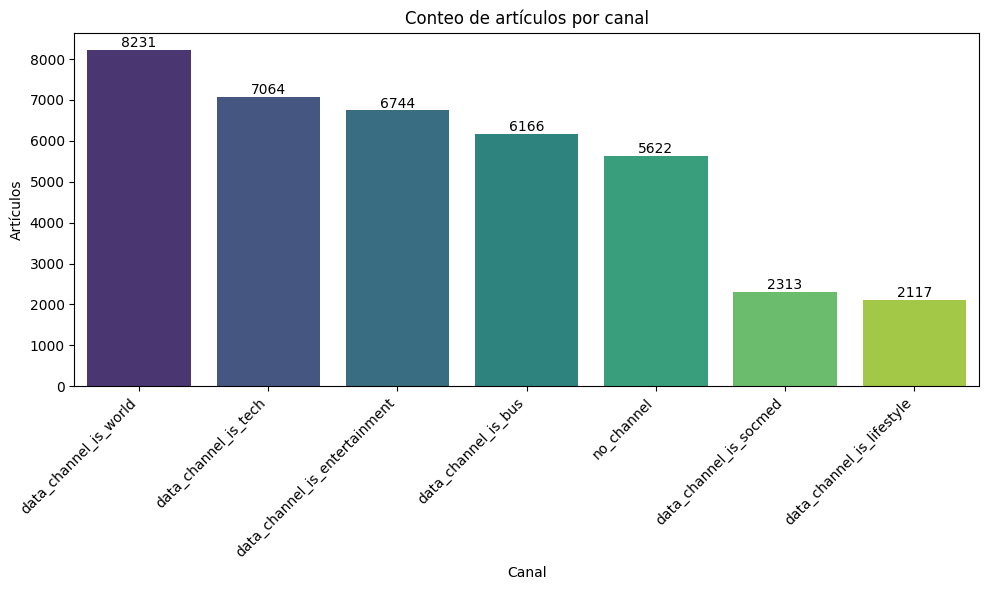

In [165]:
channel_cols = ['data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus',
                'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world']

# Calcula los artículos por canal
channel_counts = df_clean[channel_cols].sum()

# Calcula los artículos que no tienen chanel
df_clean['no_channel'] = (df_clean[channel_cols].sum(axis=1) == 0).astype(int)
no_channel_count = df_clean['no_channel'].sum()

# Agrega el conteo de no_channel
channel_counts['no_channel'] = no_channel_count

# Convierte el conteo a df para graficar
channel_counts_df = channel_counts.reset_index()
channel_counts_df.columns = ['Channel', 'Count']
channel_counts_df = channel_counts_df.sort_values(by='Count', ascending=False)

# Grafica el conteo de artículos por canal
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Channel', y='Count', data=channel_counts_df, palette='viridis', hue='Channel', legend=False) # Assign x to hue and set legend=False
plt.title('Conteo de artículos por canal')
plt.xlabel('Canal')
plt.ylabel('Artículos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Agrega etiquetas de datos
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')


plt.show()

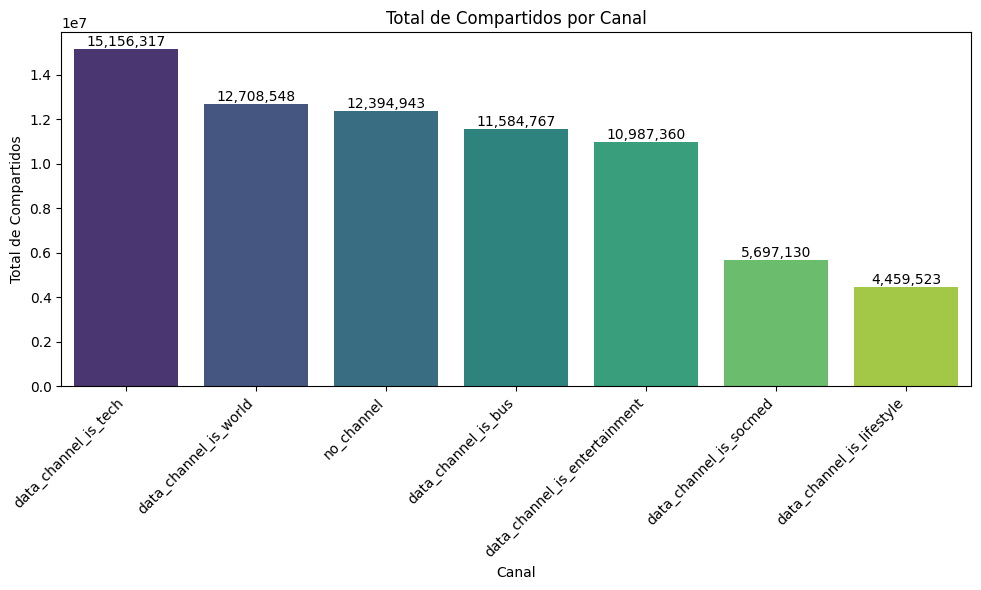

In [166]:
# Calcular cantidad de artículos por canal
channel_shares = df_clean[channel_cols].multiply(df_clean['shares'], axis=0).sum()

# Calcular cantidad de artículos sin canal
df_clean['no_channel_flag'] = (df_clean[channel_cols].sum(axis=1) == 0).astype(int)
no_channel_shares = df_clean[df_clean['no_channel_flag'] == 1]['shares'].sum()

# Agregar conteo de artículos sin canal
channel_shares['no_channel'] = no_channel_shares

# Conversión a dataframe
channel_shares_df = channel_shares.reset_index()
channel_shares_df.columns = ['Channel', 'Total Shares']
channel_shares_df = channel_shares_df.sort_values(by='Total Shares', ascending=False)

# Graficar el conteo de artículos por canal
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Channel', y='Total Shares', data=channel_shares_df, palette='viridis', hue='Channel', legend=False)
plt.title('Total de Compartidos por Canal')
plt.xlabel('Canal')
plt.ylabel('Total de Compartidos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Agrega etiquetas de datos
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

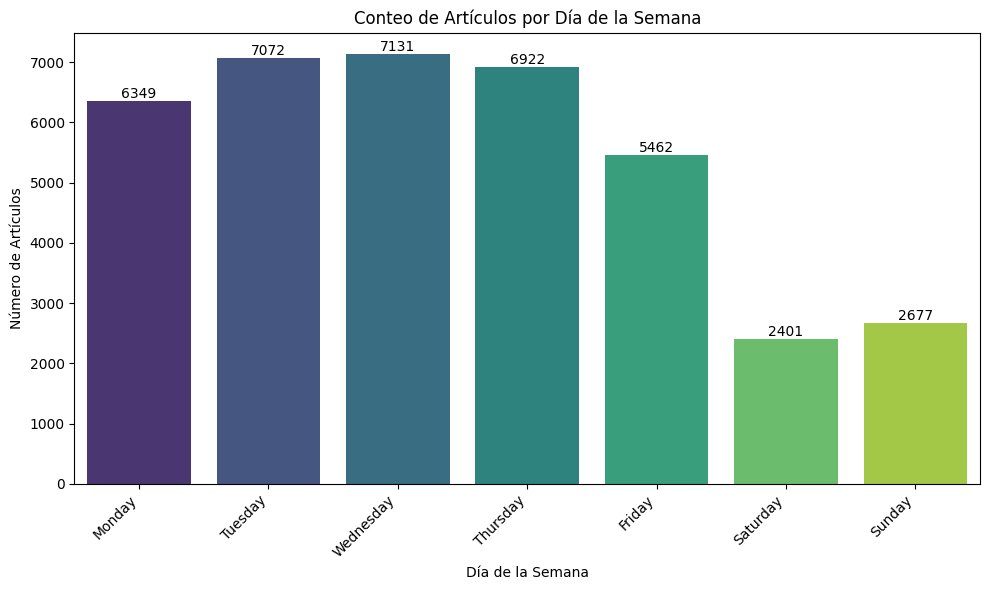

In [167]:
# Obten los días de la semana
weekday_cols = ['weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
                'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday',
                'weekday_is_sunday']

# Cuenta los artículos pro día de la semana
weekday_counts = df_clean[weekday_cols].sum()

# Renombra columnas con los días de la semana
weekday_counts.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Grafica los artículos publicados por día de la semana
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette='viridis', hue=weekday_counts.index, legend=False) # Assign x to hue and set legend=False
plt.title('Conteo de Artículos por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Número de Artículos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Añade etiqueta de datos
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

In [168]:
# Obten top 20 de artículos con más compartidos
top_20_articles = df_clean.sort_values(by='shares', ascending=False).head(20)

print("Top 20 articles with the most shares:")
display(top_20_articles[['url', 'shares']])

Top 20 articles with the most shares:


,url,shares
40321,http://mashable.com/2013/03/05/breakfast-food-...,8300.0
28389,http://mashable.com/2014/07/07/dead-cellphone-...,8300.0
29849,http://mashable.com/2014/07/29/leonardo-dicapr...,8300.0
6333,http://mashable.com/2013/05/03/modern-disney-p...,8300.0
39187,http://mashable.com/2014/12/18/marcel-the-shel...,8300.0
7067,http://mashable.com/2013/05/18/stop-sign-water/,8300.0
26164,NaN,8300.0
6407,http://mashable.com/2013/05/06/best-movie-soun...,8300.0
13151,http://mashable.com/2013/09/17/stock-photography/,8300.0
14072,http://mashable.com/2013/10/04/silk-road-by-th...,8300.0


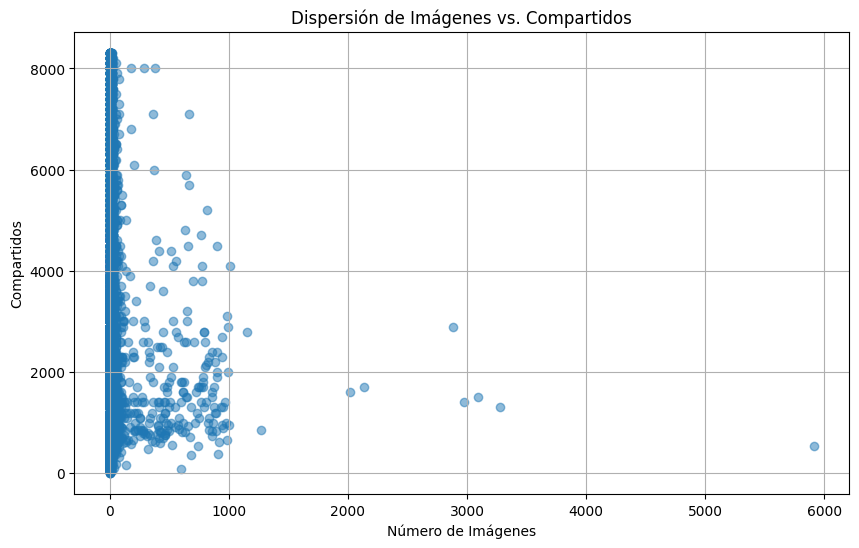

In [169]:
# Diagrama de dispersión de num_imgs vs shares
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['num_imgs'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Imágenes vs. Compartidos')
plt.xlabel('Número de Imágenes')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

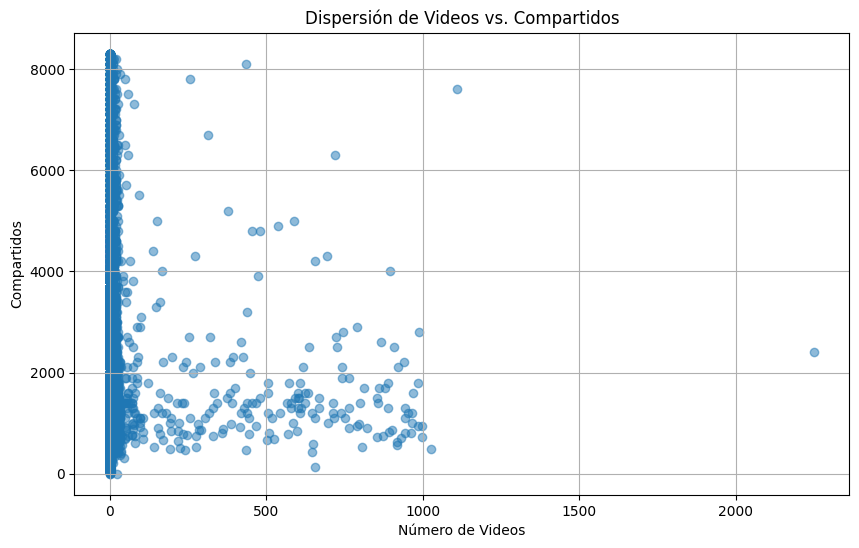

In [170]:
# Diagrama de dispersión de num_videos vs shares
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['num_videos'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Videos vs. Compartidos')
plt.xlabel('Número de Videos')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

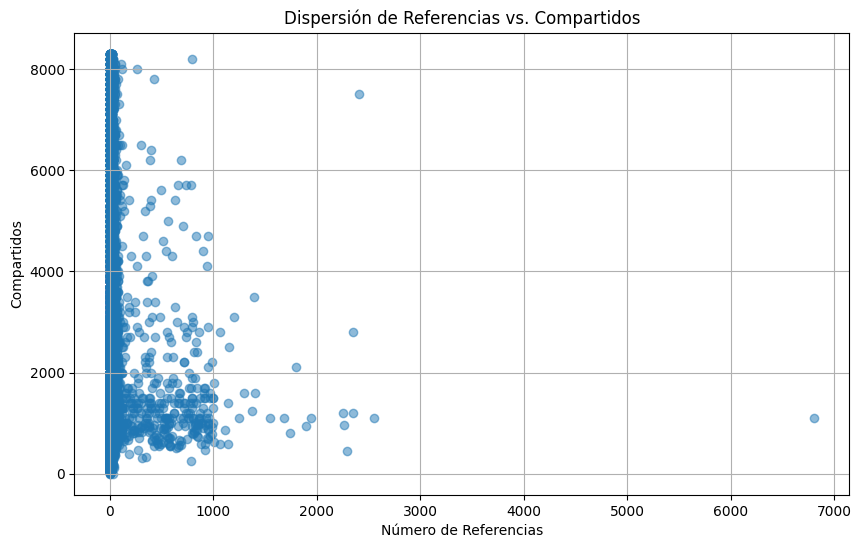

In [171]:
# Diagrama de dispersión de num_hrefs vs shares
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['num_hrefs'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Referencias vs. Compartidos')
plt.xlabel('Número de Referencias')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

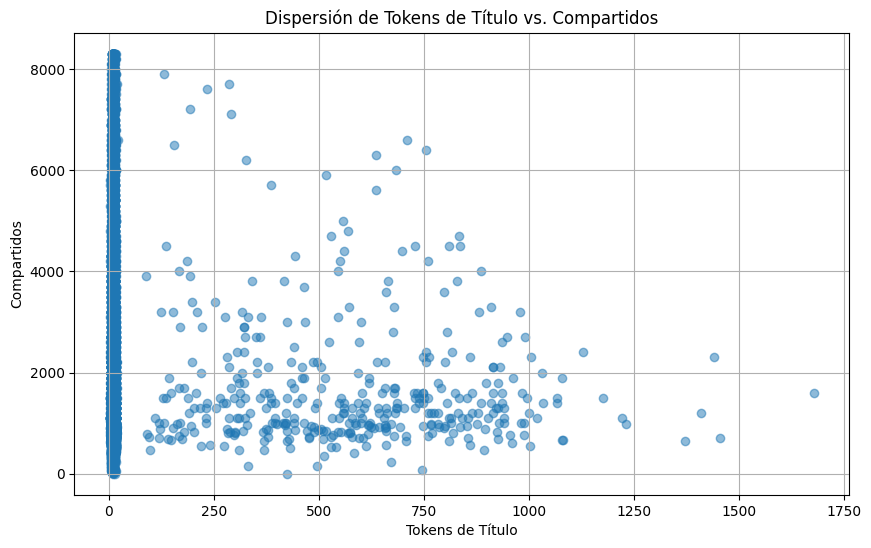

In [172]:
# Diagrama de dispersión de num_hrefs vs shares
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['n_tokens_title'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Tokens de Título vs. Compartidos')
plt.xlabel('Tokens de Título')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

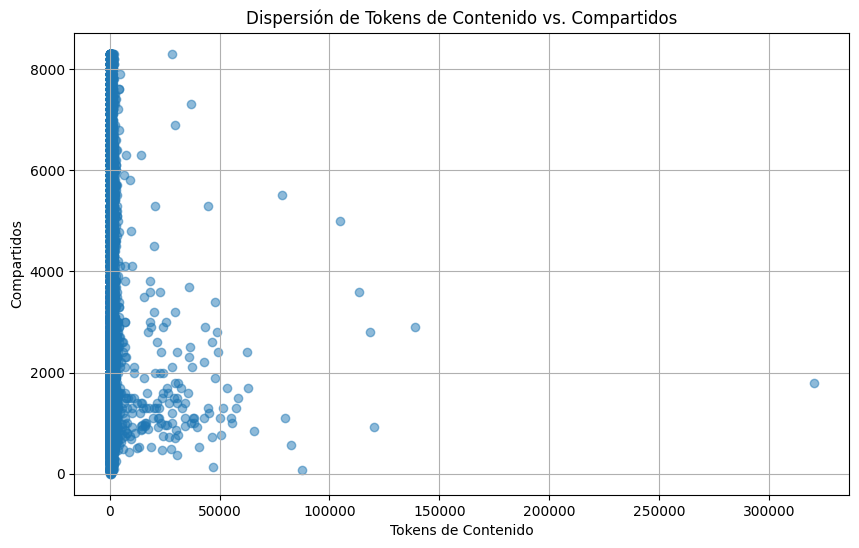

In [173]:
# Diagrama de dispersión de num_hrefs vs shares
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['n_tokens_content'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Tokens de Contenido vs. Compartidos')
plt.xlabel('Tokens de Contenido')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

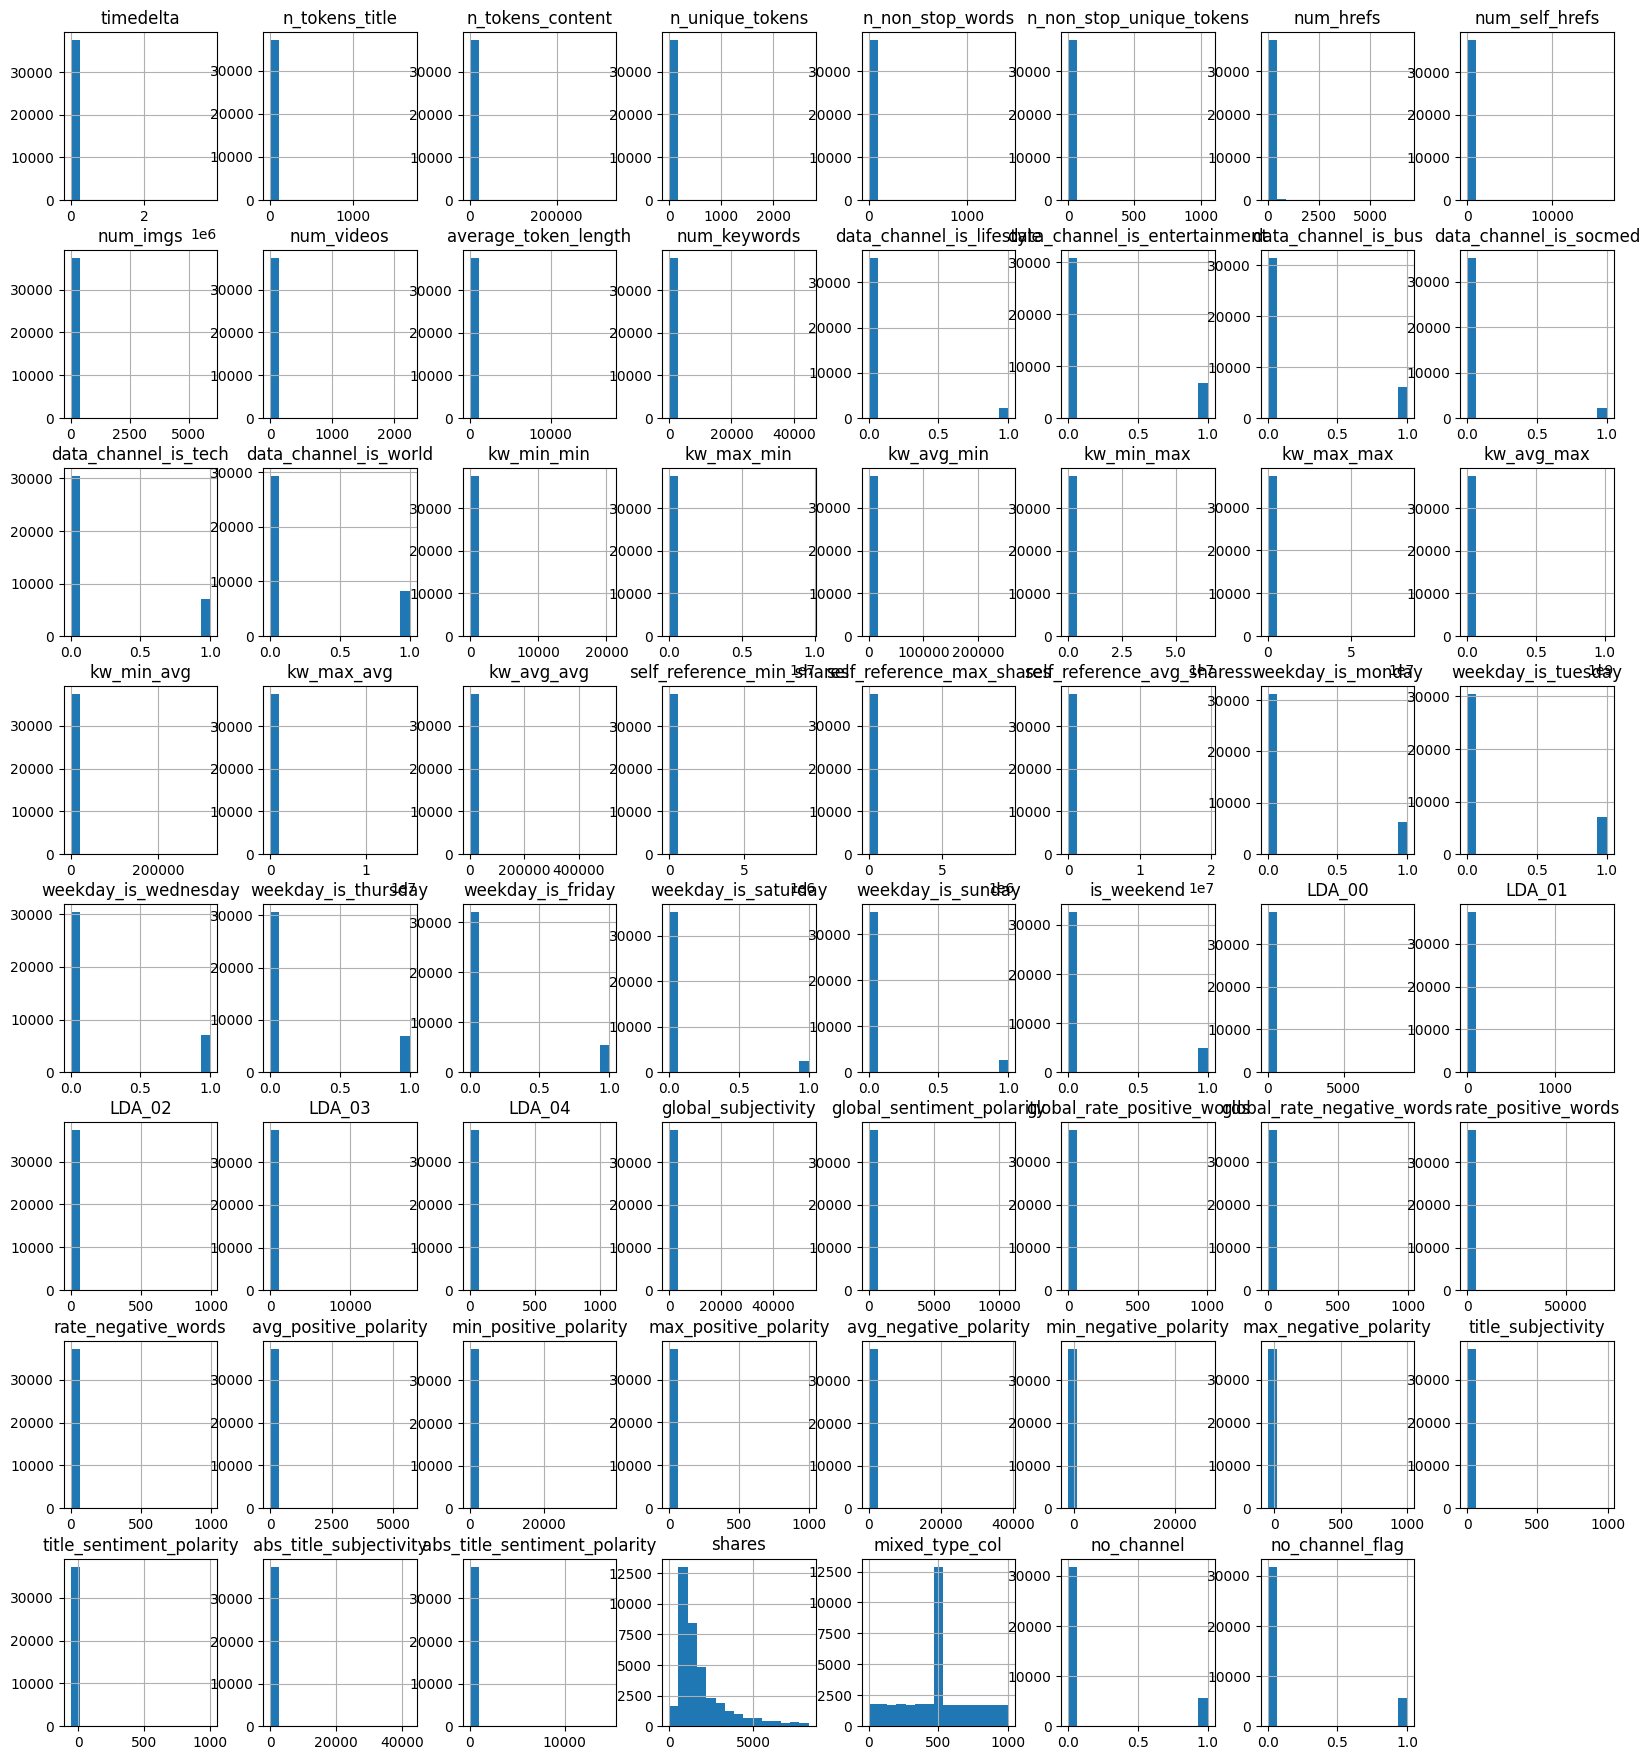

In [174]:
# Looking at the distributions
df_clean.hist(bins=15, figsize=(20, 22))
plt.show()

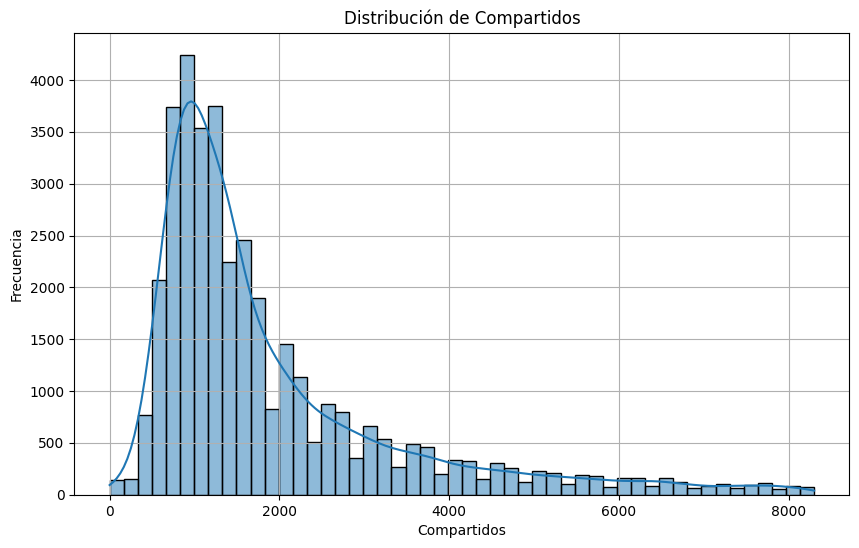

In [175]:
# Generar un histograma de la columna 'shares'
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['shares'], bins=50, kde=True)
plt.title('Distribución de Compartidos')
plt.xlabel('Compartidos')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# **Parte 3**. Preprocesamiento y feature engineering

In [176]:
# Importamos librerías para esta etapa
import scipy.stats as stats
from scipy.stats.distributions import norm

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
!pip install category_encoders
from category_encoders.binary import BinaryEncoder

# *Preprocesamiento*

In [177]:
# Extraer fecha y título de la columna 'url'
# Manejar posibles valores NaN en la columna 'url'

df_processed = df_clean.copy()

# Convertir a cadena y eliminar espacios en blanco, creando la columna 'url_cleaned'
df_processed['url_cleaned'] = df_processed['url'].astype(str).str.strip()

# Usar regex para encontrar el patrón de fecha YYYY/MM/DD
date_pattern = r'/(\d{4})/(\d{2})/(\d{2})/'
date_match = df_processed['url_cleaned'].str.extract(date_pattern) # Extraer la fecha y guardarla en una variable temporal

df_processed['article_year'] = date_match[0]
df_processed['article_month'] = date_match[1]
df_processed['article_day'] = date_match[2]

# Convertir columnas de fecha a numérico, forzando errores a NaN
df_processed['article_year'] = pd.to_numeric(df_processed['article_year'], errors='coerce')
df_processed['article_month'] = pd.to_numeric(df_processed['article_month'], errors='coerce')
df_processed['article_day'] = pd.to_numeric(df_processed['article_day'], errors='coerce')

# Extraer título (última parte de la ruta URL antes de la barra final)
# Eliminar esquema, netloc y barra final, luego dividir por '/' y tomar la última parte
df_processed['article_title'] = df_processed['url_cleaned'].str.split('/').str[-2]

# Modifica el nombre del artículo, inicia con mayúsculas y remueve guiones
df_processed['article_title'] = df_processed['article_title'].str.replace('-', ' ').str.title()


print("Nuevas columnas 'article_year', 'article_month', 'article_day' y 'article_title' creadas y modificadas.")


display(df_processed[['url', 'article_year', 'article_month', 'article_day', 'article_title']].head())

Nuevas columnas 'article_year', 'article_month', 'article_day' y 'article_title' creadas y modificadas.


,url,article_year,article_month,article_day,article_title
0,http://mashable.com/2013/01/07/amazon-instant-...,2013.0,1.0,7.0,Amazon Instant Video Browser
1,http://mashable.com/2013/01/07/ap-samsung-spon...,2013.0,1.0,7.0,Ap Samsung Sponsored Tweets
2,http://mashable.com/2013/01/07/apple-40-billio...,2013.0,1.0,7.0,Apple 40 Billion App Downloads
3,http://mashable.com/2013/01/07/astronaut-notre...,2013.0,1.0,7.0,Astronaut Notre Dame Bcs
4,http://mashable.com/2013/01/07/att-u-verse-apps/,2013.0,1.0,7.0,Att U Verse Apps


In [178]:
# Columnas booleanas para días de la semana
weekday_cols = ['weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
                'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday',
                'weekday_is_sunday']
weekday_names = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

# Crear la columna 'day_of_week'
def get_weekday_name(row):
    for i, col in enumerate(weekday_cols):
        if row[col] == 1:
            return weekday_names[i]
    return 'unknown' # Handle cases where no weekday is marked as 1

df_processed['day_of_week'] = df_processed[weekday_cols].apply(get_weekday_name, axis=1)

print("Columna 'day_of_week' creada")


# Columnas booleanas para canales de datos
channel_cols = ['data_channel_is_lifestyle', 'data_channel_is_entertainment',
                'data_channel_is_bus', 'data_channel_is_socmed',
                'data_channel_is_tech', 'data_channel_is_world']
channel_names = ['lifestyle', 'entertainment', 'bus', 'socmed', 'tech', 'world']

# Crear la columna 'data_channel'
def get_channel_name(row):
    for i, col in enumerate(channel_cols):
        if row[col] == 1:
            return channel_names[i]
    return 'no_channel' # Handle cases where no channel is marked as 1

df_processed['data_channel'] = df_processed[channel_cols].apply(get_channel_name, axis=1)

print("Columna 'data_channel' creada")


# Mostrar las primeras filas del dataframe con las nuevas columnas
print("\nPrimeras filas del dataframe con variables de día de semana y canal:")
display(df_processed[['day_of_week', 'data_channel']].head())

print("\nInformación del dataframe con las nuevas columnas:")
print(df_processed[['day_of_week', 'data_channel']].info())

print("\nFin del preprocesamiento")

Columna 'day_of_week' creada
Columna 'data_channel' creada

Primeras filas del dataframe con variables de día de semana y canal:


,day_of_week,data_channel
0,monday,entertainment
1,monday,bus
2,monday,bus
3,monday,entertainment
4,monday,tech



Información del dataframe con las nuevas columnas:
<class 'pandas.core.frame.DataFrame'>
Index: 37471 entries, 0 to 40434
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   day_of_week   37471 non-null  object
 1   data_channel  37471 non-null  object
dtypes: object(2)
memory usage: 878.2+ KB
None

Fin del preprocesamiento


# *Feature engeneering*

In [179]:
# Histograma y gráfico Q-Q para conocer comportamiento de las variables importantes

def diagnostic_plots(df_processed, variable):
    plt.figure(figsize=(10,4))
    plt.subplot(1, 2, 1)
    df_clean[variable].hist(bins=30, color='gray', edgecolor='black')
    plt.title(f"Histogram of {variable}")
    plt.subplot(1, 2, 2)
    stats.probplot(df_clean[variable], dist="norm", plot=plt)
    plt.gca().get_lines()[0].set_color('gray')
    plt.gca().get_lines()[1].set_color('red')
    plt.title(f"Q-Q plot of {variable}")
    plt.show()

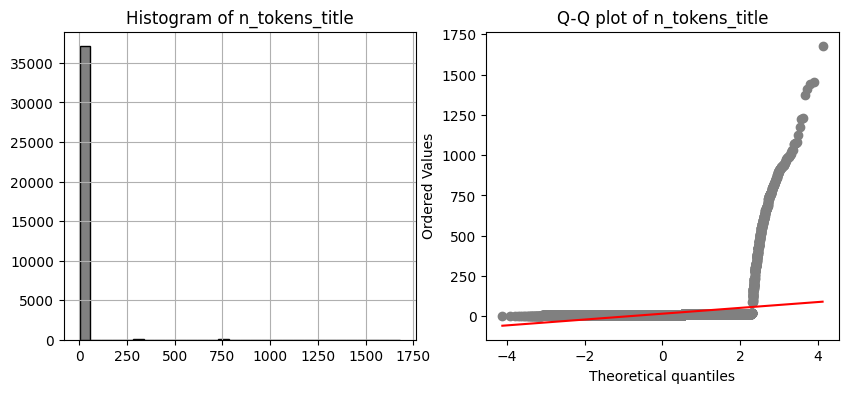

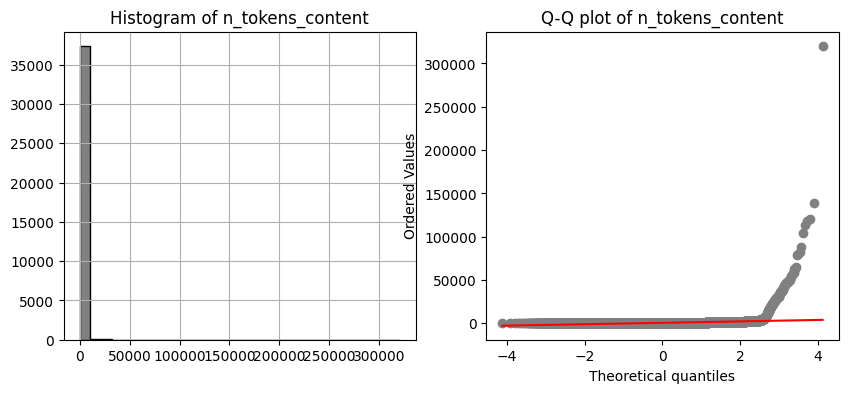

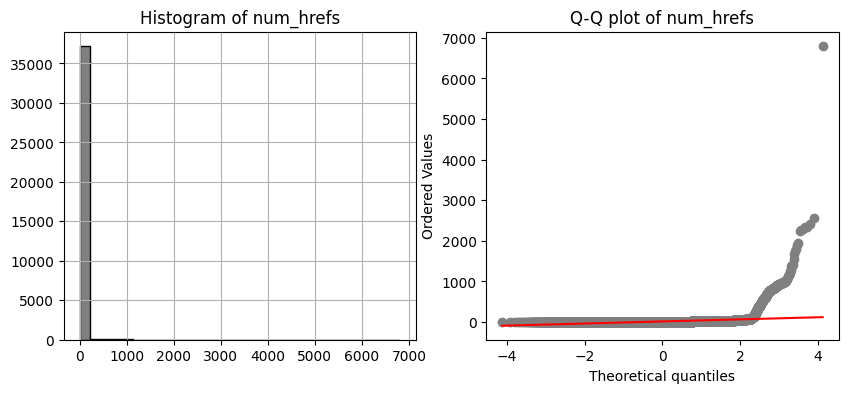

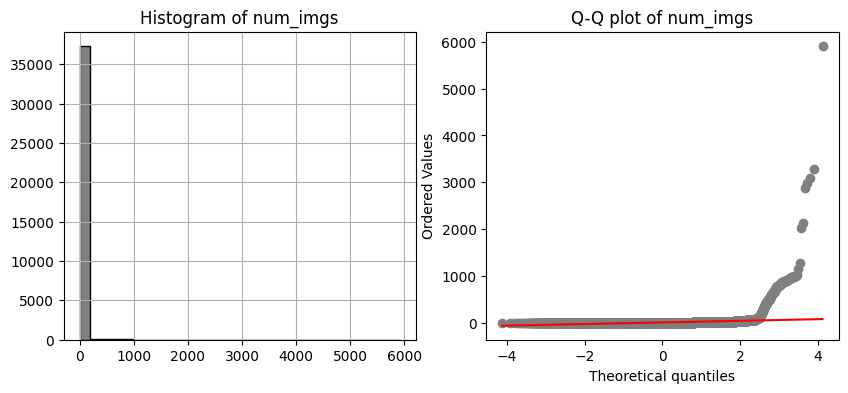

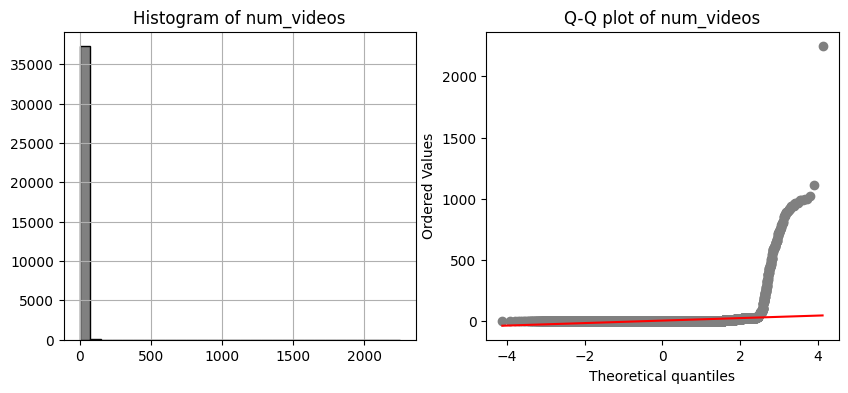

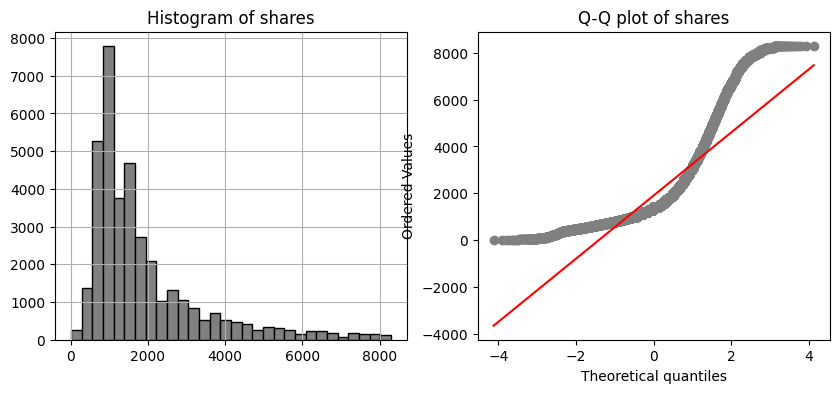

In [180]:
for col in df_clean[important_numeric_cols]:
    diagnostic_plots(df_processed, col)

In [181]:
#Transformación de las variables numéricas con método Yeo Jhonson

transformer = PowerTransformer(method="yeo-johnson", standardize=False)#Configuramos la transformación
transformer.fit(df_processed[important_numeric_cols])#Ajustamos el transformador
transf_df = pd.DataFrame(transformer.transform(df_processed[important_numeric_cols]), columns=important_numeric_cols, index=df_processed.index)#Transformamos cada variable del dataframe
print("Lambdas estimadas:", transformer.lambdas_)
print(transf_df.head())

Lambdas estimadas: [-1.09899599  0.21609636 -0.12660055 -0.5722886  -1.55574016 -0.03072561]
   n_tokens_title  n_tokens_content  num_hrefs  num_imgs  num_videos    shares
0        0.855623         10.216114   1.456063  0.572178        -0.0  5.799255
1        0.837477         10.710283   1.271458  0.572178        -0.0  5.947753
2        0.837477         10.097772   1.271458  0.572178        -0.0  6.550336
3        0.837477         13.336810   1.997340  0.572178        -0.0  6.371624
4        0.859870         16.277624   2.493143  1.441390        -0.0  5.667158


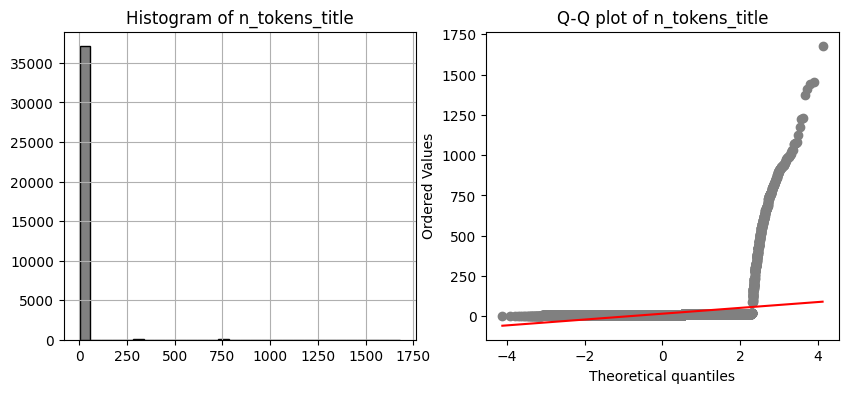

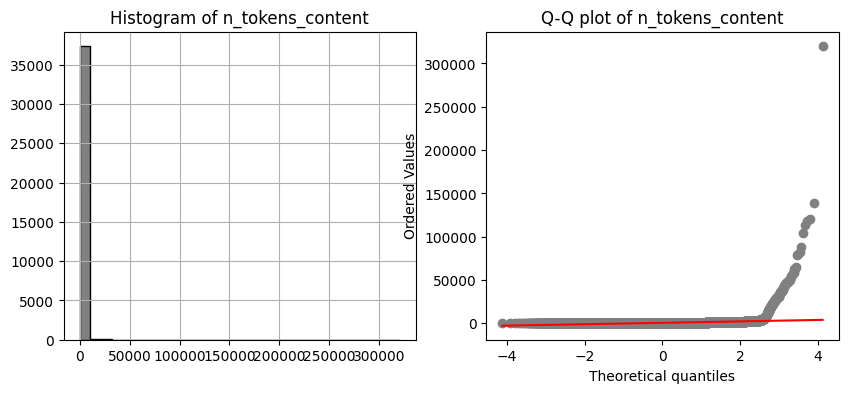

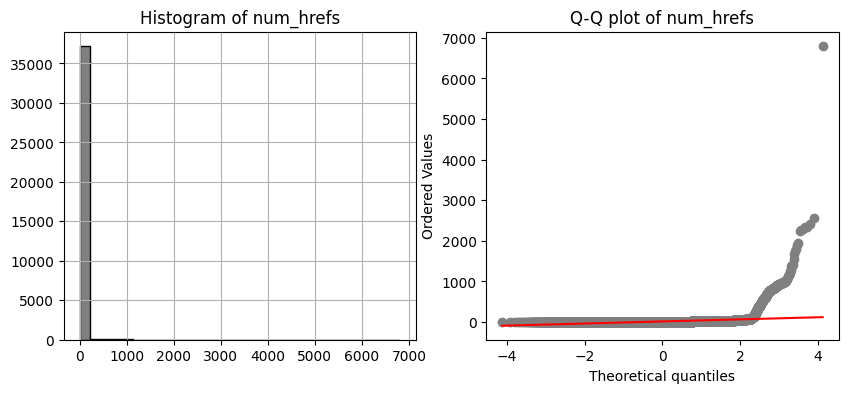

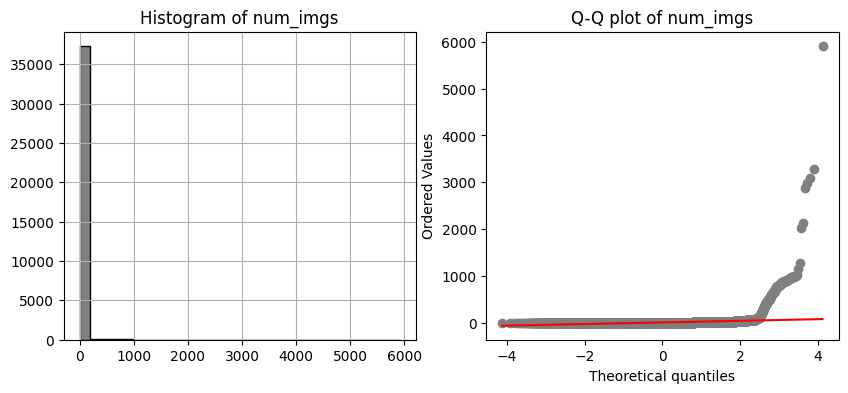

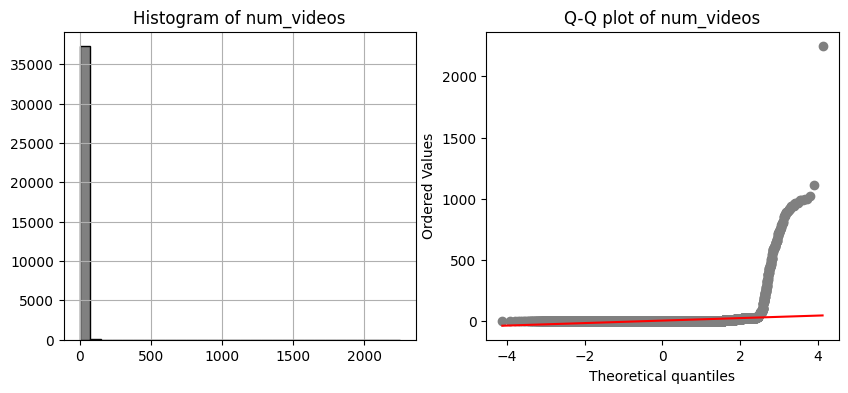

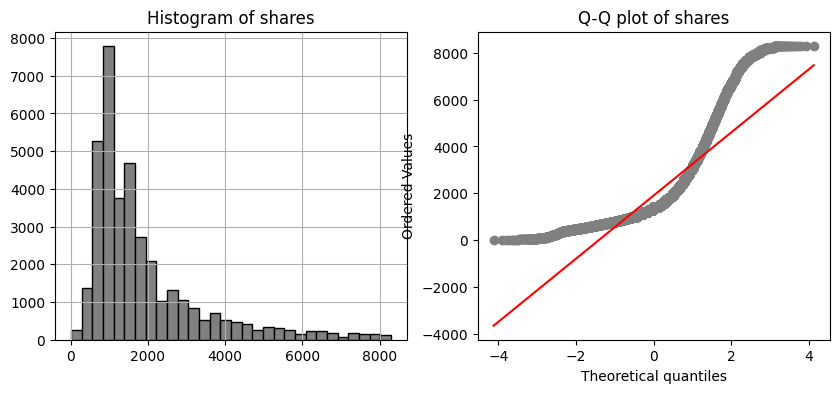

In [182]:
#Histograma y gráfico Q-Q para observar efecto de la transformación

for col in df_processed[important_numeric_cols]:
    diagnostic_plots(df_processed, col)

In [183]:
# Escalado de variables con min max
scaler=MinMaxScaler()
minmax_df = pd.DataFrame(scaler.fit_transform(transf_df), columns=transf_df.columns, index=transf_df.index)

print(minmax_df.head())

   n_tokens_title  n_tokens_content  num_hrefs  num_imgs  num_videos    shares
0        0.801176          0.152454   0.273966  0.329739         0.0  0.710665
1        0.734409          0.159828   0.239232  0.329739         0.0  0.731303
2        0.734409          0.150688   0.239232  0.329739         0.0  0.815050
3        0.734409          0.199023   0.375810  0.329739         0.0  0.790213
4        0.816802          0.242909   0.469098  0.830655         0.0  0.692306


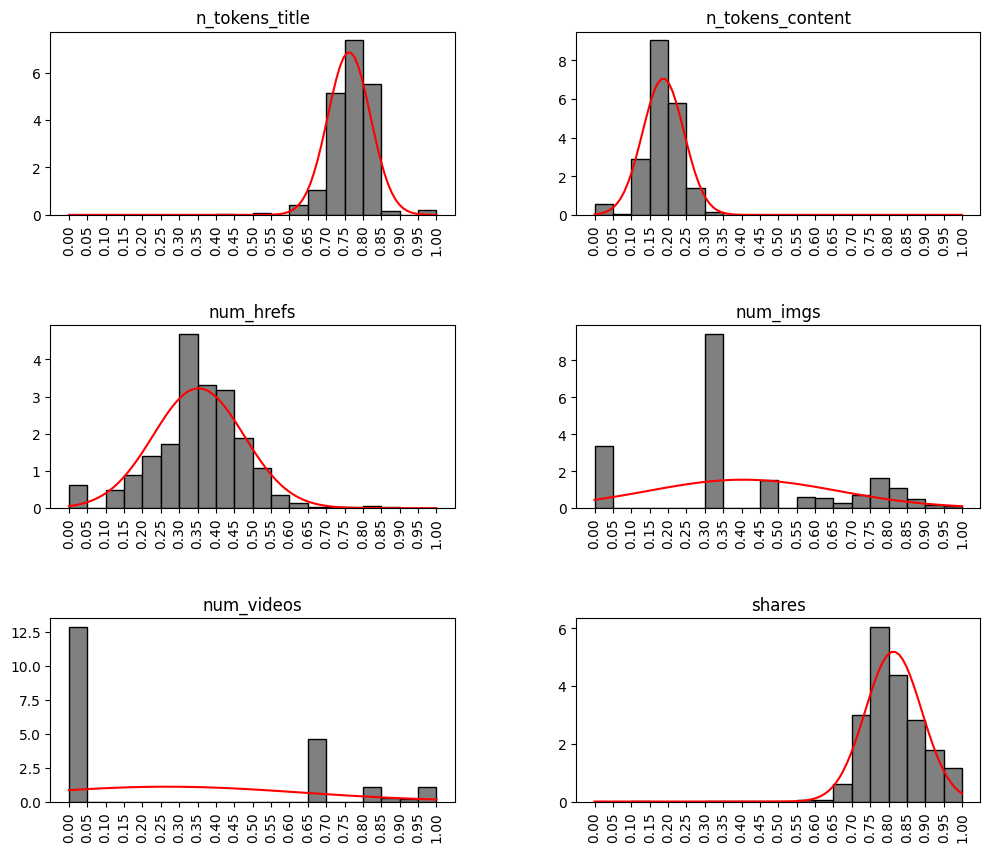

In [184]:
#Graficación de variables excaladas
fig, axes = plt.subplots(3,2, figsize=(12,10))
plt.subplots_adjust(wspace=.3, hspace=.6)

axes = axes.ravel()
for col, ax in zip(minmax_df.columns, axes):
  n, bins, edges = ax.hist(minmax_df[col], color='gray', bins=20, edgecolor='black', density=True)
  ax.set_xticks(bins)
  ax.tick_params(axis='x',rotation=90)
  ax.set(title=f'{col}', xlabel=None)

  x = np.linspace(np.min(minmax_df[col]), np.max(minmax_df[col]), 100)
  y = norm.pdf(x, np.mean(minmax_df[col]), np.std(minmax_df[col]))
  ax.plot(x, y, color='red')


In [185]:
# Renombra columnas de df min max agregando '_scaled' al final
minmax_df.columns = [col + '_scaled' for col in minmax_df.columns]
minmax_df.head()

,n_tokens_title_scaled,n_tokens_content_scaled,num_hrefs_scaled,num_imgs_scaled,num_videos_scaled,shares_scaled
0,0.801176,0.152454,0.273966,0.329739,0.0,0.710665
1,0.734409,0.159828,0.239232,0.329739,0.0,0.731303
2,0.734409,0.150688,0.239232,0.329739,0.0,0.815050
3,0.734409,0.199023,0.375810,0.329739,0.0,0.790213
4,0.816802,0.242909,0.469098,0.830655,0.0,0.692306


In [186]:
#Cardinalidad variables categoricas

var_categoricas = df_processed.describe(include='object').columns

highly_cardinal_variables = [];
few_cardinal_variables = [];

for col in var_categoricas:
  df_processed[col].nunique()
  if df_processed[col].nunique() >= 100:
    highly_cardinal_variables.append(col)
  else:
    few_cardinal_variables.append(col)
print(f'Variables con alta cardinalidad: {highly_cardinal_variables}')
print(f'Variables con baja cardinalidad: {few_cardinal_variables}')

Variables con alta cardinalidad: ['url', 'url_cleaned', 'article_title']
Variables con baja cardinalidad: ['day_of_week', 'data_channel']


In [187]:
# Codificar variables categóricas con baja cardinalidad

encoder = OneHotEncoder(drop='first')
encoded_data = encoder.fit_transform(df_processed[few_cardinal_variables])
onehot_df = pd.DataFrame(encoded_data.toarray(), columns=encoder.get_feature_names_out())
onehot_df

,day_of_week_monday,day_of_week_saturday,day_of_week_sunday,day_of_week_thursday,day_of_week_tuesday,day_of_week_unknown,day_of_week_wednesday,data_channel_entertainment,data_channel_lifestyle,data_channel_no_channel,data_channel_socmed,data_channel_tech,data_channel_world
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37466,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
37467,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
37468,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
37469,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [188]:
# Agrega variables escaladas al df
df_encoded = pd.concat([df_processed, minmax_df, onehot_df], axis=1)

print('Fin del feature engineering')

df_encoded.head()

Fin del feature engineering


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,day_of_week_thursday,day_of_week_tuesday,day_of_week_unknown,day_of_week_wednesday,data_channel_entertainment,data_channel_lifestyle,data_channel_no_channel,data_channel_socmed,data_channel_tech,data_channel_world
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
